# Visualizing Gene Program Embeddings

This tutorial demonstrates how to visualize Tripso embeddings. We'll explore both:
1. **Gene Program (GP) embeddings** - gene program-specific representations that capture specialized biological processes
2. **Global cell embeddings** - representations of entire cells in the learned latent space (though this is not the main focus of tripso)


## Prerequisites
- Completed model training (see previous tutorials)
- Embeddings generated and saved in `output_global/embeddings/`

In [1]:
from datasets import load_from_disk, concatenate_datasets
import scanpy as sc
import anndata as ad
import numpy as np

## 2. Load pre-computed embeddings and convert to AnnData

The model generates embeddings during inference for train, validation, and test sets. Each embedding dataset contains:
- `cell_token`: Global cell representation (learned by the model's global attention mechanism)
- `<GP name>`: Gene program-specific embeddings for each gene program
- `<GP_name>_prop_genes` : Proportion of total GP genes expressed in each cell
- Metadata: `idx`, (unique cell barcode) `cell_type`, `tissue`, etc.

**Note**: For this tutorial, we use only the test set for simplicity. In a full analysis, you may want to concatenate all splits to avoid losing rare populations.

In [2]:
# Option 1: Load all data splits (commented out for tutorial simplicity)
# train = load_from_disk("output_global/embeddings/train_set")
# val = load_from_disk("output_global/embeddings/val_set")
# test = load_from_disk("output_global/embeddings/test_set")
# data = concatenate_datasets([train, val, test])

# Option 2: Load only test set for faster tutorial execution
data = load_from_disk("output_global/embeddings/test_set")
data

Dataset({
    features: ['GP_USF1', 'GP_USF1_num_genes', 'GP_NFE2L2', 'GP_NFE2L2_num_genes', 'GP_RUNX1', 'GP_RUNX1_num_genes', 'GP_FOXO3', 'GP_FOXO3_num_genes', 'GP_MYB', 'GP_MYB_num_genes', 'GP_E2F4', 'GP_E2F4_num_genes', 'GP_IRF1', 'GP_IRF1_num_genes', 'GP_GATA1', 'GP_GATA1_num_genes', 'GP_CTCF', 'GP_CTCF_num_genes', 'GP_MYCN', 'GP_MYCN_num_genes', 'GP_ATF4', 'GP_ATF4_num_genes', 'GP_ATF3', 'GP_ATF3_num_genes', 'GP_JUNB', 'GP_JUNB_num_genes', 'GP_JUND', 'GP_JUND_num_genes', 'GP_GATA2', 'GP_GATA2_num_genes', 'GP_DDIT3', 'GP_DDIT3_num_genes', 'GP_TAL1', 'GP_TAL1_num_genes', 'GP_FLI1', 'GP_FLI1_num_genes', 'GP_ELF1', 'GP_ELF1_num_genes', 'GP_RUNX3', 'GP_RUNX3_num_genes', 'GP_KLF2', 'GP_KLF2_num_genes', 'GP_PRDM1', 'GP_PRDM1_num_genes', 'GP_IRF2', 'GP_IRF2_num_genes', 'GP_NFYB', 'GP_NFYB_num_genes', 'GP_ZBTB7A', 'GP_ZBTB7A_num_genes', 'gene_encoder_cls', 'cell_token', 'length', 'AuthorCellType', 'AuthorCellType_Broad', 'cell_type', 'Sorting', 'Study', 'donor', 'sex', 'development_stage',

### Create AnnData Object from Global Embeddings

Convert the HuggingFace dataset to Scanpy's AnnData format:
- `X`: The global cell embeddings (high-dimensional vectors)
- `obs`: Cell metadata including cell type and tissue annotations

## 3. Visualize Gene Program-Specific Embeddings

We first explore **gene program (GP) embeddings**, which is the main novelty of the Tripso model. 

### Example: GATA1 Gene Program

GATA1 is a master transcription factor for erythroid (red blood cell) development. Therefore we expect the GATA1 embedding space to capture different cell states in erythroid differentiaiton. 


In [3]:
# Create AnnData object using GATA1 gene program embeddings in slot X
gata1 = sc.AnnData(
    X=np.array(data["GP_GATA1"]),  # GATA1-specific cell representations
    obs=data.select_columns(['idx', 'AuthorCellType', 'AuthorCellType_Broad', 'cell_type', 'age_group', 'Study', ]).to_pandas()
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
# Subset to erythroid lineage cell types
# These represent the developmental trajectory where GATA1 is most relevant
gata1 = gata1[
    gata1.obs['AuthorCellType_Broad'].isin(['HSC MPP',                    
                                 'MEP',                      
                                 'Early Erythroid',
                                 'Late Erythroid',  
                                ])
]

In [5]:
# Compute UMAP on GATA1 GP embedding space
sc.pp.neighbors(gata1)
sc.tl.umap(gata1)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 256 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


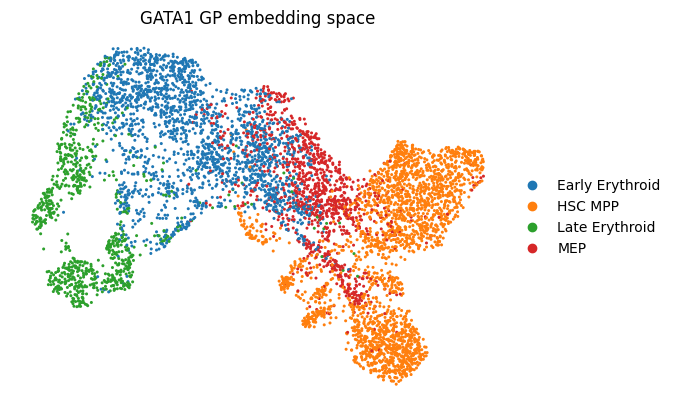

In [6]:
# Visualize GATA1 GP embedding colored by cell type
# Here the cells cluster according to their differentiation stage
sc.pl.umap(gata1, color=['AuthorCellType_Broad'], title='GATA1 GP embedding space', frameon=False)